# RIFT-EEG Analysis Pipeline

**Author:** Christos Dalamarinis  
**Date:** March 2026    
**Status:** In developement

---

## Overview

This notebook implements the full RIFT-EEG analysis pipeline.
RIFT (Rapid Invisible Frequency Tagging) is a technique in which visual stimuli are
flickered at **60 Hz** — perceptually invisible, yet the brain entrains to the flicker,
producing a steady-state response detectable in the EEG.

**Core question:** Does the EEG signal show reliable phase-locking to the 60 Hz flicker?  
This is assessed via coherence between each EEG channel and a reference signal at the tagging frequency.

**Pipeline:**
1. Phase 1 — Data Loading and Initial Inspection
2. Phase 2 — Preprocessing
3. Phase 3 — Epoching and Epoch-Level Quality Control
4. Phase 4 — RIFT Coherence Analysis
5. Phase 5 — Statistical Testing
6. Phase 6 — Documentation, Reproducibility, and Export

---

## Libraries

| Library | Role |
|---|---|
| `mne` | Loading, preprocessing, epoching, spectral analysis |
| `numpy` / `scipy` | FFT, cross-spectral density, coherence, signal processing |
| `pandas` | Behavioral data, event logs, tabular summaries |
| `matplotlib` / `seaborn` | Visualization (spectra, topographies, coherence maps) |
| `autoreject` | Automated epoch rejection and repair |
| `mne-icalabel` | Automated IC classification (eye blinks, muscle, etc.) |
| `mne-connectivity` | Spectral connectivity (coherence) between EEG and reference signal |
| `statsmodels` / `pingouin` | Statistical testing, permutation tests |

---

# Phase 1 — Data Loading and Initial Inspection

Before any preprocessing, we load the raw `.bdf` recordings and verify that the data are intact and as expected.

**Steps:**
1. Load the raw data
2. Inspect the recording metadata (sampling rate, channels, duration, events)
3. Set channel types and attach the electrode montage
4. Visual inspection of the raw signal
5. Power Spectral Density (PSD) check 

---
## Setup: Imports and Configuration

In [4]:
import os
import glob
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mne.set_log_level('warning')
%matplotlib inline

print(f'MNE version   : {mne.__version__}')
print(f'NumPy version : {np.__version__}')

MNE version   : 1.11.0
NumPy version : 2.2.6


In [5]:
# -- Configuration ------------------------------------------------------------
# Set DATA_DIR to the "data" folder that contains the sub* subfolders.

# DATA_DIR = r'your/path/to/your/data'               #! change if data live elsewhere other than current working directory
DATA_DIR       = os.path.join(os.getcwd(), 'data')   #! change if data live elsewhere other than current working directory
EXPECTED_SFREQ = 1024                                # expected sampling rate (Hz)
TAGGING_FREQ   = 60.0                                # RIFT flicker frequency (Hz)

# Channel type assignments -- BioSemi ActiveTwo layout
MASTOID_CHANNELS = ['EXG5', 'EXG6']
EOG_CHANNELS     = ['EXG1', 'EXG2', 'EXG3', 'EXG4']
UNUSED_CHANNELS  = ['EXG7', 'EXG8']

# -- Auto-detect subjects from data/subX/ subfolders --------------------------
# Expected structure:
#   data/
#     sub1/
#       sub_1.bdf
#       output_s1.mat
#       awareness_s1.mat
#     sub2/
#       ...

bdf_files = sorted(glob.glob(os.path.join(DATA_DIR, 'sub*', '*.bdf')))          #! change if .bdf files are named differently

if not bdf_files:
    raise FileNotFoundError(f'No .bdf files found under: {DATA_DIR}/sub*/')

subjects = [
    {'subject_id': f'sub-{i+1:02d}', 'bdf_path': f}
    for i, f in enumerate(bdf_files)
]

print(f'Data directory : {DATA_DIR}')
print(f'Subjects found : {len(subjects)}')
for s in subjects:
    print(f"  {s['subject_id']}  ->  {os.path.relpath(s['bdf_path'], DATA_DIR)}")

Data directory : c:\Users\dalam\OneDrive\Vrije Universiteit Amsterdam\Neuropsychology\Thesis\Coding - Thesis\WM data\Data Analysis\RIFT-analysis\data
Subjects found : 4
  sub-01  ->  sub1\sub_01.bdf
  sub-02  ->  sub2\sub_02.bdf
  sub-03  ->  sub3\sub_03.bdf
  sub-04  ->  sub4\sub_04.bdf


---
## 1.1 — Load the Raw Data

EEG data is in **`.bdf` format** from Biosemi.  `preload=True` loads the full data into memory, required for most preprocessing operations.

In [6]:
# Load all subjects into raw_dict
raw_dict = {}

for s in subjects:
    print(f"Loading {s['subject_id']}  ({os.path.basename(s['bdf_path'])}) ...", end=' ')
    raw_dict[s['subject_id']] = mne.io.read_raw_bdf(s['bdf_path'], preload=True, verbose=False)
    r = raw_dict[s['subject_id']]
    print(f"{r.info['sfreq']} Hz  |  {r.info['nchan']} ch  |  {r.times[-1]:.0f} s")

print(f'\nAll {len(raw_dict)} subject(s) loaded.') 

Loading sub-01  (sub_01.bdf) ... 1024.0 Hz  |  73 ch  |  3335 s
Loading sub-02  (sub_02.bdf) ... 1024.0 Hz  |  73 ch  |  3745 s
Loading sub-03  (sub_03.bdf) ... 

C:\Users\dalam\AppData\Local\Temp\ipykernel_11824\263735141.py:6: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw_dict[s['subject_id']] = mne.io.read_raw_bdf(s['bdf_path'], preload=True, verbose=False)


1024.0 Hz  |  73 ch  |  3762 s
Loading sub-04  (sub_04.bdf) ... 

C:\Users\dalam\AppData\Local\Temp\ipykernel_11824\263735141.py:6: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw_dict[s['subject_id']] = mne.io.read_raw_bdf(s['bdf_path'], preload=True, verbose=False)


1024.0 Hz  |  73 ch  |  4523 s

All 4 subject(s) loaded.


In [7]:
# -- Select subject for inspection --------------------------------------------
#! Change SUBJECT_IDX to inspect a different subject (0 = first, 1 = second, ...).

SUBJECT_IDX = 2

SUBJECT_ID = subjects[SUBJECT_IDX]['subject_id']
raw        = raw_dict[SUBJECT_ID]

print(f'Active subject: {SUBJECT_ID}  ({os.path.basename(subjects[SUBJECT_IDX]["bdf_path"])})')

Active subject: sub-03  (sub_03.bdf)


---
## 1.2 — Inspect the Metadata

Before touching the data, verify that the recording metadata is correct.

**Check:**
1. **Sampling rate (`raw.info['sfreq']`)** — confirm it matches the recording system and is high enough for 60 Hz
2. **Channel count and names** — no duplicates or unnamed channels
3. **Channel types** — correctly labeled as EEG, EOG, STIM, etc.
4. **Recording duration (`raw.times[-1]`)** — sanity-check total trials and blocks against protocol
5. **Events/annotations (`raw.annotations`)** — triggers present and matching experimental design

In [8]:
print(raw.info)
print(f'Duration: {raw.times[-1]:.1f} seconds')
print(f'Channels: {raw.info["nchan"]}')
print(f'Sampling rate: {raw.info["sfreq"]} Hz')
print(raw.annotations)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF7, AF3, F1, F3, F5, F7, FT7, FC5, FC3, FC1, C1, C3, C5, ...
 chs: 72 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 208.0 Hz
 meas_date: 2026-03-12 14:12:07 UTC
 nchan: 73
 projs: []
 sfreq: 1024.0 Hz
 subject_info: <subject_info | his_id: >
>
Duration: 3762.0 seconds
Channels: 73
Sampling rate: 1024.0 Hz
<Annotations | 0 segments>


In [ ]:
# Verify sampling rate and Nyquist requirement for RIFT
sfreq   = raw.info['sfreq']
nyquist = sfreq / 2

if sfreq == EXPECTED_SFREQ:
    print(f'[OK]      Sampling rate matches expected: {sfreq} Hz')
else:
    print(f'[WARNING] Sampling rate {sfreq} Hz != expected {EXPECTED_SFREQ} Hz')

if nyquist > TAGGING_FREQ:
    print(f'[OK]      Nyquist ({nyquist} Hz) > tagging frequency ({TAGGING_FREQ} Hz)')
else:
    print(f'[ERROR]   Sampling rate too low to capture {TAGGING_FREQ} Hz signal!')

In [ ]:
# Channel names and counts
print(f'Channel count : {raw.info["nchan"]}')
print('Channel names :')
for i, ch in enumerate(raw.info['ch_names']):
    print(f'  [{i:3d}]  {ch}')

In [9]:
# Annotations summary
print(f'Annotations ({len(raw.annotations)} total):')
print(raw.annotations)

if len(raw.annotations) > 0:
    descriptions = pd.Series([a['description'] for a in raw.annotations])
    print('\nAnnotation description counts:')
    print(descriptions.value_counts())
else:
    print('[WARNING] No annotations found. Check your trigger / Status channel.')

Annotations (0 total):
<Annotations | 0 segments>
[WARNING] No annotations found. Check your trigger / Status channel.


---
## 1.3 — Set Channel Types and Montage

Most `.bdf` files do not embed channel type information reliably.
We manually assign types for non-EEG channels, then attach a standard electrode montage.

```python
MASTOID_CHANNELS = ['EXG5', 'EXG6']
EOG_CHANNELS     = ['EXG1', 'EXG2', 'EXG3', 'EXG4']
UNUSED_CHANNELS  = ['EXG7', 'EXG8']
```

The montage provides 3D electrode positions required for topographic plotting, interpolation,
re-referencing, and source localization.

> If your cap uses a non-standard layout, load a custom montage from a `.sfp`, `.elc`, `.tsv`,
> or digitization file instead of `standard_1020`.

In [10]:
# Assign channel types
#
#! EOG (EXG1-4): labeled as 'eog' so MNE treats them correctly in ICA and artifact detection.
#
# UNUSED (EXG7-8): labeled as 'misc' to exclude them from all EEG operations.
#
#! MASTOIDS (EXG5-6): intentionally labeled as 'misc' here for two reasons:
#   1. The standard_1020 montage has no positions for 'EXG5'/'EXG6' (it uses
#      names like TP9/TP10). Leaving them as 'eeg' would create positionless
#      EEG channels that silently get excluded from topomaps, making Phase 1
#      inspection messier than it needs to be.
#   2. In Phase 1 we are only inspecting — we do not need them in the EEG pool yet.
#      Keeping them as 'misc' cleanly separates them from the 64 scalp channels
#      for all Phase 1 checks (raw plots, PSD, topomaps, SNR).
#
#! In Phase 2, before re-referencing, they will be reassigned to 'eeg' with
# set_channel_types() so MNE can use them as the linked-mastoid reference,
# and then dropped from the data after the reference is applied.

ch_type_map = {}
ch_type_map.update({ch: 'eog'  for ch in EOG_CHANNELS     if ch in raw.ch_names})
ch_type_map.update({ch: 'misc' for ch in MASTOID_CHANNELS if ch in raw.ch_names})
ch_type_map.update({ch: 'misc' for ch in UNUSED_CHANNELS  if ch in raw.ch_names})

raw.set_channel_types(ch_type_map)

print('Channel types set:')
for ch, t in ch_type_map.items():
    print(f'  {ch:8s}  ->  {t}')
print()
print('Note: EXG5/EXG6 (mastoids) are temporarily set to misc.')
print('They will be reassigned to eeg in Phase 2 before re-referencing.')

Channel types set:
  EXG1      ->  eog
  EXG2      ->  eog
  EXG3      ->  eog
  EXG4      ->  eog
  EXG5      ->  misc
  EXG6      ->  misc
  EXG7      ->  misc
  EXG8      ->  misc

Note: EXG5/EXG6 (mastoids) are temporarily set to misc.
They will be reassigned to eeg in Phase 2 before re-referencing.


C:\Users\dalam\AppData\Local\Temp\ipykernel_11824\627280120.py:25: RuntimeWarning: The unit for channel(s) EXG5, EXG6, EXG7, EXG8 has changed from V to NA.
  raw.set_channel_types(ch_type_map)


In [11]:
# Attach standard 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='warn')

print('Montage set: standard_1020')
print(f'Montage contains {len(montage.ch_names)} channel positions')

Montage set: standard_1020
Montage contains 94 channel positions


In [ ]:
# Visualize electrode layout
fig = raw.plot_sensors(show_names=True, kind='topomap')
fig.suptitle(f'{SUBJECT_ID} — Electrode positions (standard_1020)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 1.4 — Visual Inspection of the Raw Data

Plot the raw continuous data and scroll through it to assess recording quality.

**What to look for:**
1. **Flat channels** — zero or near-zero amplitude (likely disconnected electrodes)
2. **Excessively noisy channels** — dramatically higher amplitude or high-frequency noise vs. neighbors
3. **Large slow drifts** — very slow oscillations (< 0.1 Hz) from movement or poor electrode impedance
4. **Muscle artifacts** — high-frequency bursts (> 20 Hz) from jaw clenching, swallowing, or movement
5. **Eye blinks and saccades** — large, slow deflections at frontal electrodes (Fp1, Fp2)
6. **Electrical line noise** — sustained **50 Hz** hum (Netherlands mains frequency)
7. **Event markers** — triggers appear at expected times and in the expected pattern

In [ ]:
# Interactive scrollable plot
# Switch to Qt backend so you can scroll through the recording.
%matplotlib qt

raw.plot(
    duration=20,
    n_channels=30,
    scalings='auto',
    title=f'{SUBJECT_ID} — Raw EEG (scroll to inspect)',
    block=True,    # pauses execution until the window is closed
)

%matplotlib inline

# Print bad channels marked during inspection
if raw.info['bads']:
    print(f'Bad channels marked ({len(raw.info["bads"])}): {raw.info["bads"]}')
else:
    print('No bad channels marked.')

#! NOTE 12/03/2026 -> try to make this plot only for the electrodes covering V1/V2 (e.g. O1, O2, Oz, POz, Pz) ,
#! since those are the ones expected to show the strongest RIFT response.

In [ ]:
# Static snapshot — first 20 seconds (for inline / non-interactive environments)
fig = raw.plot(
    duration=20,
    n_channels=30,
    scalings='auto',
    title=f'{SUBJECT_ID} — Raw EEG (first 20 s)',
    show=False,
)
plt.tight_layout()
plt.show()

In [12]:
# Record your findings from the visual inspection.
# Update these after scrolling through the data.

inspection_notes = {
    'flat_channels'   : [],    # e.g. ['Cz', 'T8']
    'noisy_channels'  : [],    # e.g. ['FT9']
    'slow_drifts'     : False,
    'muscle_artifacts': False,
    'eye_blinks'      : False,
    'line_noise_50hz' : False,
    'other_notes'     : '',
}

print('Visual inspection notes:')
for k, v in inspection_notes.items():
    print(f'  {k:20s}: {v}')

Visual inspection notes:
  flat_channels       : []
  noisy_channels      : []
  slow_drifts         : False
  muscle_artifacts    : False
  eye_blinks          : False
  line_noise_50hz     : False
  other_notes         : 


---
## 1.5 — Check Power Spectral Density (PSD)

This is a **general data quality check** — the goal here is to assess the overall health of the recording, <ins>not to detect the RIFT signal</ins>. At this stage, the data is raw and unpreprocessed, so do not be alarmed if you cannot see a clear 60 Hz peak. That is expected and normal.

**What to look for:**
1. **Overall spectral shape** — the spectrum should follow a smooth 1/f curve (power decreasing with frequency), with a visible alpha bump around 8–13 Hz. This is your basic sanity check: *does this look like EEG?*
2. **50 Hz line noise** — a sharp spike at 50 Hz (Netherlands mains frequency) indicates electrical interference that will need to be removed in Phase 2 with a notch filter
3. **Excessive high-frequency power** — a broad elevation above ~40 Hz across many channels usually indicates muscle artifacts
4. **Outlier channels** — channels with a clearly different spectral profile from their neighbours (much higher or lower power across the board) are likely bad channels
5. **Low-frequency drift** — disproportionately high power at very low frequencies (< 1 Hz) suggests slow drifts from movement or poor electrode contact

> **On the 60 Hz RIFT signal:** <ins>You may or may not see a small peak at 60 Hz here</ins> — if it is visible, that is a good sign, but its absence does not indicate a problem. Raw PSD computed over the entire recording is a blunt tool: it averages over RIFT-on and RIFT-off periods alike, discards phase information entirely, and has no noise reduction applied. Detecting the RIFT response properly requires restricting the analysis to **RIFT-on time windows**, cleaning the data, and using **phase-sensitive measures such as coherence** — all of which are handled in Phase 4.

In [ ]:
# Full PSD up to 100 Hz — all EEG channels
raw.compute_psd(fmax=100).plot()

In [ ]:
# PSD zoomed around the tagging frequency (40–80 Hz) — channel average
psd_zoom = raw.compute_psd(fmin=40, fmax=80, picks='eeg')     #! fmin=40 - fmax=80 by default
fig = psd_zoom.plot(average=True, show=False)
ax  = fig.axes[0]
ax.axvline(TAGGING_FREQ, color='red',  linestyle='--', alpha=0.8,
           label=f'{TAGGING_FREQ} Hz (RIFT tagging)')
ax.axvline(50.0,         color='gray', linestyle=':',  alpha=0.6,
           label='50 Hz (line noise)')
ax.legend()
fig.suptitle(f'{SUBJECT_ID} — PSD zoomed 40-80 Hz', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Quantify the 60 Hz peak: compute SNR per channel
# SNR = power at tagging freq / mean power of neighboring bins (±2-5 Hz away)

psd_full = raw.compute_psd(fmin=30, fmax=100, picks='eeg')
freqs    = psd_full.freqs
power    = psd_full.get_data()   # shape: (n_channels, n_freqs)

foi_idx = np.argmin(np.abs(freqs - TAGGING_FREQ))

neighbor_mask = (
    ((freqs >= TAGGING_FREQ - 5) & (freqs <= TAGGING_FREQ - 2)) |
    ((freqs >= TAGGING_FREQ + 2) & (freqs <= TAGGING_FREQ + 5))
)

signal_power = power[:, foi_idx]
noise_power  = power[:, neighbor_mask].mean(axis=1)
snr_db       = 10 * np.log10(signal_power / noise_power)
ch_names     = psd_full.ch_names

top_idx = np.argsort(snr_db)[::-1][:10]
print(f'Top 10 channels by {TAGGING_FREQ} Hz SNR (raw, unpreprocessed):')
print(f'{"Channel":>10}  {"SNR (dB)":>10}')
print('-' * 24)
for idx in top_idx:
    print(f'{ch_names[idx]:>10}  {snr_db[idx]:>10.2f}')

In [ ]:
# Topographic map of 60 Hz SNR
# Expected: highest SNR over occipital/parietal channels (Oz, O1, O2, POz, PO3, PO4)

fig, ax = plt.subplots(figsize=(6, 5))
im, _   = mne.viz.plot_topomap(
    snr_db,
    psd_full.info,  # raw.info contains all 73 channels
    axes=ax,
    show=False,
    cmap='RdBu_r',
)
plt.colorbar(im, ax=ax, label='SNR (dB)')
ax.set_title(f'{SUBJECT_ID} — {TAGGING_FREQ} Hz SNR topography (raw)')
plt.tight_layout()
plt.show()

In [ ]:
# Topographic map of 60 Hz SNR
# Expected: highest SNR over occipital/parietal channels (Oz, O1, O2, POz, PO3, PO4)

mastoid_mask = np.array([ch not in MASTOID_CHANNELS for ch in ch_names])
info_plot    = mne.pick_info(psd_full.info, np.where(mastoid_mask)[0])

fig, ax = plt.subplots(figsize=(6, 5))
im, _   = mne.viz.plot_topomap(
    snr_db[mastoid_mask],
    info_plot,
    axes=ax,
    show=False,
    cmap='RdBu_r',
)
plt.colorbar(im, ax=ax, label='SNR (dB)')
ax.set_title(f'{SUBJECT_ID} — {TAGGING_FREQ} Hz SNR topography (raw)')
plt.tight_layout()
plt.show()


In [ ]:
# PSD topography — broadband power per channel
# Channels that look very different from their neighbors may be bad.

fig = raw.compute_psd(fmax=100, picks='eeg').plot_topomap(show=False)
fig.suptitle(f'{SUBJECT_ID} — PSD topography (broadband power)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 1.6 — Exploratory PSD on RIFT-On Epochs (Raw, Unpreprocessed)

This is an **optional sanity check** — we epoch the raw data around RIFT-on triggers and compute the PSD only over those windows, to see if restricting to flicker-active periods makes a 60 Hz elevation more visible compared to section 1.5.

**Important caveats:**
- The data is still raw and unpreprocessed — artifacts, noise, and drifts are all still present
- This epoching is **temporary and exploratory only** — it operates on a copy of `raw` and does not alter it in any way
- Not seeing a 60 Hz peak here is still perfectly normal for the same reasons discussed in 1.5
- This is **not** the RIFT analysis — that happens in Phase 4 after preprocessing, using coherence

In [ ]:
# -- 1.6 Exploratory PSD on RIFT-on epochs -----------------------------------
#! Works entirely on a COPY of the raw data. The original raw object is never touched.

# Step 1: copy raw — raw itself is not affected from this point on
raw_copy = raw.copy()

# Step 2: extract events from the trigger channel
events_explore = mne.find_events(
    raw_copy,
    stim_channel='Status',
    shortest_event=1,
    mask=255,
    verbose=False,
)

# Remove BioSemi hardware status byte
events_explore = events_explore[events_explore[:, 2] != 254]

# Step 3: isolate RIFT-on trigger (code 40)
rift_on_events = events_explore[events_explore[:, 2] == 40]

print(f'RIFT-on events found (trigger 40): {len(rift_on_events)}')

# Step 4: epoch around RIFT-on onset
# tmin=-0.2 : 200 ms before the flicker starts (pre-stimulus buffer)
# tmax= 2.5 : covers the full 2000 ms RIFT window plus 500 ms after it ends
epochs_explore = mne.Epochs(
    raw_copy,
    rift_on_events,
    event_id={'rift_on': 40},
    tmin=-0.2,
    tmax=2.5,
    baseline=None,       # no baseline — this is exploratory only
    picks='eeg',
    preload=True,
    verbose=False,
)

print(f'Epochs created: {len(epochs_explore)}')

# Step 5: compute and plot PSD on the RIFT-on epochs
fig = epochs_explore.compute_psd(fmin=40, fmax=80).plot(average=True, show=False)
ax  = fig.axes[0]
ax.axvline(TAGGING_FREQ, color='red',  linestyle='--', alpha=0.8,
           label=f'{TAGGING_FREQ} Hz (RIFT tagging)')
ax.axvline(50.0,         color='gray', linestyle=':',  alpha=0.6,
           label='50 Hz (line noise)')
ax.legend()
fig.suptitle(
    f'{SUBJECT_ID} — PSD on RIFT-on epochs (raw, unpreprocessed, 40-80 Hz)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

# Step 6: clean up — discard the temporary objects to free memory
del raw_copy, epochs_explore, events_explore, rift_on_events
print('Temporary objects deleted. raw is unchanged.')

---
## Phase 1 Summary

Run the cell below after completing all checks to get a concise summary before moving to **Phase 2 (Preprocessing)**.

In [ ]:
print('=' * 60)
print(f'PHASE 1 SUMMARY -- {SUBJECT_ID}')
print('=' * 60)
print(f'File           : {RAW_FILE}')
print(f'Sampling rate  : {raw.info["sfreq"]} Hz')
print(f'Total channels : {raw.info["nchan"]}')
print(f'EEG channels   : {len(mne.pick_types(raw.info, eeg=True))}')
print(f'EOG channels   : {len(mne.pick_types(raw.info, eog=True))}')
print(f'Duration       : {raw.times[-1]:.1f} s  ({raw.times[-1] / 60:.1f} min)')
print(f'Annotations    : {len(raw.annotations)}')
print()
print('Potential bad channels (from visual inspection):')
print(f'  Flat    : {inspection_notes["flat_channels"]}')
print(f'  Noisy   : {inspection_notes["noisy_channels"]}')
print()
print(f'Top 3 channels by {TAGGING_FREQ} Hz SNR (raw):')
for idx in top_idx[:3]:
    print(f'  {ch_names[idx]}: {snr_db[idx]:.2f} dB')
print()
print('Next step: Phase 2 -- Preprocessing')

---

# Phase 2 — Preprocessing

Clean the raw data before epoching. The goal is to remove noise and artifacts while **preserving the 60 Hz RIFT signal**.

**Steps:**
1. Mark bad channels
2. Filtering (0.1 Hz HP → 100 Hz LP → notch at 50/100/150 Hz)
3. Downsample to 512 Hz
4. Re-reference to linked mastoids (EXG5, EXG6)
5. ICA artifact removal
6. Interpolate bad channels

> **Critical constraint:** Do **not** low-pass filter below 60 Hz, and do **not** notch-filter at 60 Hz — that is our signal of interest.

---
## 2.1 — Mark Bad Channels

Based on the visual inspection and PSD review in Phase 1, mark any channels that are clearly unusable (flat, excessively noisy, or disconnected).

Marked channels are **not dropped** — they are excluded from filtering, ICA, and re-referencing, then **interpolated** in step 2.6 using spherical spline interpolation.

In [13]:
# -- 2.1 Mark Bad Channels ---------------------------------------------------
# Populate from Phase 1 visual inspection notes.
# Edit the lists below manually if you spotted additional bad channels.

#! Update these lists based on your Phase 1 inspection findings.
raw.info['bads'] = (
    inspection_notes['flat_channels'] +
    inspection_notes['noisy_channels']
)

print(f'Bad channels marked ({len(raw.info["bads"])}): {raw.info["bads"]}')
print()
print('These channels are excluded from filtering, ICA, and re-referencing.')
print('They will be interpolated in step 2.6 after ICA.')

Bad channels marked (0): []

These channels are excluded from filtering, ICA, and re-referencing.
They will be interpolated in step 2.6 after ICA.


---
## 2.2 — Filtering

Three sequential filters are applied:

1. **High-pass 0.1 Hz** — removes slow drifts without distorting the signal
2. **Low-pass 100 Hz** — removes high-frequency noise; set well above 60 Hz to preserve the RIFT signal
3. **Notch at 50, 100, 150 Hz** — removes Netherlands mains frequency and its harmonics

> ⚠️ **Do NOT notch at 60 Hz** — that is your tagging frequency.  
> ⚠️ A standard 40 Hz low-pass (common in ERP pipelines) would **destroy** the RIFT signal.

In [ ]:
# FIR filter parametersg
h = mne.filter.create_filter(
    raw.get_data(picks='eeg'), raw.info['sfreq'],
    l_freq=0.1, h_freq=100.0,
    fir_design='firwin', verbose=True
)
print(f'Filter kernel length: {len(h)}')
print(f'Filter kernel sum (DC gain): {h.sum():.6f}')

Setting up band-pass filter from 0.1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 33793 samples (33.001 s)

Filter kernel length: 33793
Filter kernel sum (DC gain): -0.000000


In [15]:
# -- 2.2a Bandpass filter: 0.1 – 100 Hz -------------------------------------
# High-pass 0.1 Hz : removes slow drifts
# Low-pass 100 Hz  : RIFT-adjusted — preserves 60 Hz tagging frequency + headroom
#                    (a standard 40 Hz LP would completely destroy the RIFT signal)

#! Promote EXG5/EXG6 misc → eeg BEFORE filtering so they receive the same bandpass and notch as the scalp EEG channels. This is required because:
#   1. raw.filter() skips 'misc' channels by default
#   2. In step 2.4 we subtract EXG5/EXG6 from the EEG — if they were not
#      filtered, we would be subtracting an unfiltered signal (large DC offset,
#      slow drift) from filtered EEG, which corrupts the entire dataset.
# They remain typed as 'eeg' from here onwards until they are dropped in 2.4.
raw.set_channel_types({'EXG5': 'eeg', 'EXG6': 'eeg'})
print('EXG5, EXG6 promoted: misc → eeg (will be filtered alongside EEG channels)')

print(f'Applying bandpass filter (0.1 – 100.0 Hz) to {SUBJECT_ID} ...')
raw.filter(l_freq=0.1, h_freq=100.0, fir_design='firwin', verbose=False)   #! applying FIR filter
print('[OK] Bandpass 0.1 – 100.0 Hz applied (includes EXG5, EXG6).')

C:\Users\dalam\AppData\Local\Temp\ipykernel_11824\652664970.py:12: RuntimeWarning: The unit for channel(s) EXG5, EXG6 has changed from NA to V.
  raw.set_channel_types({'EXG5': 'eeg', 'EXG6': 'eeg'})


EXG5, EXG6 promoted: misc → eeg (will be filtered alongside EEG channels)
Applying bandpass filter (0.1 – 100.0 Hz) to sub-03 ...
[OK] Bandpass 0.1 – 100.0 Hz applied (includes EXG5, EXG6).


In [16]:
# -- 2.2b Notch filter: 50, 100, 150 Hz (Netherlands mains + harmonics) -----
# Netherlands mains frequency is 50 Hz — NOT 60 Hz.
# This means our 60 Hz tagging frequency is safely separated from line noise.
#! DO NOT add 60 Hz to this list.

print('Applying notch filter at 50, 100, 150 Hz ...')
raw.notch_filter(freqs=[50, 100, 150], verbose=False)
print('[OK] Notch filter applied (50, 100, 150 Hz).')

Applying notch filter at 50, 100, 150 Hz ...
[OK] Notch filter applied (50, 100, 150 Hz).


In [ ]:
# -- 2.2c Verify filtering: PSD after bandpass + notch -----------------------
# 50 Hz spike should be gone; 
#! The absence of a 60 Hz peak here is expected and fine at that point.

fig = raw.compute_psd(fmax=120, picks='eeg').plot(average=True, show=False)
ax  = fig.axes[0]
ax.axvline(TAGGING_FREQ, color='red',  linestyle='--', alpha=0.8,
           label=f'{TAGGING_FREQ} Hz (RIFT tagging — must be preserved)')
ax.axvline(50.0,         color='gray', linestyle=':',  alpha=0.6,
           label='50 Hz (line noise — should be absent)')
ax.axvline(100.0,        color='gray', linestyle=':',  alpha=0.4,
           label='100 Hz harmonic — should be absent')
ax.legend()
fig.suptitle(f'{SUBJECT_ID} — PSD after filtering (0.1–100 Hz BP + notch)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 2.3 — Downsampling

The original sampling rate is 1024 Hz. Downsampling to **512 Hz** halves memory use and speeds up ICA and epoching, while comfortably preserving the 60 Hz tagging frequency (Nyquist = 256 Hz >> 60 Hz).

> **Hard constraint:** Never downsample below 500 Hz for 60 Hz RIFT. MNE automatically applies an anti-aliasing low-pass filter before resampling.

In [ ]:
# -- 2.3 Downsampling --------------------------------------------------------
# 1024 Hz → 512 Hz: halves data size; Nyquist (256 Hz) >> 60 Hz tagging freq.
# MNE applies an anti-aliasing LP filter automatically before resampling.
# Constraint: NEVER go below 500 Hz for 60 Hz RIFT.

TARGET_SFREQ = 512  #! do not set below 500 Hz

assert TARGET_SFREQ >= 2 * TAGGING_FREQ * 2, (
    f'Target rate {TARGET_SFREQ} Hz is too low for {TAGGING_FREQ} Hz RIFT '
    f'(need ≥ {int(2 * TAGGING_FREQ * 2)} Hz for safe spectral estimation)'
)

print(f'Resampling from {raw.info["sfreq"]:.0f} Hz → {TARGET_SFREQ} Hz ...')
raw.resample(sfreq=TARGET_SFREQ, verbose=False)

print(f'[OK] Resampled. New rate: {raw.info["sfreq"]:.0f} Hz')
print(f'     Nyquist: {raw.info["sfreq"] / 2:.0f} Hz  >  {TAGGING_FREQ:.0f} Hz (tagging freq)')

---
## 2.4 — Re-referencing to Linked Mastoids

We use **EXG5 (left mastoid)** and **EXG6 (right mastoid)** as a linked-mastoid reference.

Three steps are required:
1. **Promote EXG5/EXG6 from `misc` to `eeg`** — they were set to `misc` in Phase 1 to avoid montage position warnings during inspection; they must be `eeg` for MNE to accept them as a reference.
2. **Apply the linked-mastoid reference** — MNE averages EXG5 and EXG6 and subtracts the result from all EEG channels.
3. **Drop EXG5/EXG6** — once used as a reference, they carry no further signal and are removed to keep the data clean.

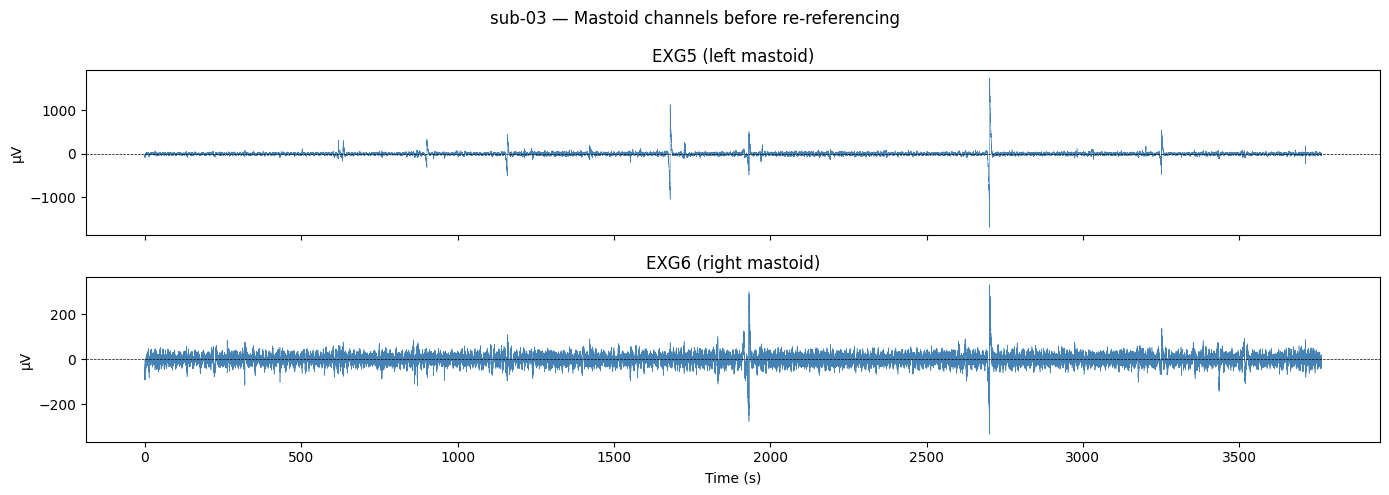

Mastoid channel statistics:
  EXG5:  range [-1692.5, 1750.6] µV  |  mean -0.0 µV  |  std 64.0 µV
  EXG6:  range [-332.9, 331.3] µV  |  mean -0.0 µV  |  std 22.7 µV

EEG channel std for comparison:
  All EEG channels (overall std): 25.7 µV

If mastoid std >> EEG std, do NOT proceed — investigate the electrode.


In [17]:
# -- 2.4 Diagnostic: inspect EXG5/EXG6 before using them as reference --------
# EXG5/EXG6 must be clean and in the same amplitude range as EEG channels.
# If they are noisy or drifting, subtracting them injects that noise into
# every EEG channel simultaneously — inflating std and shifting the mean.
#
# What to look for:
#   [OK]  Flat or very slow drift, amplitude within ±500 µV
#   [BAD] Large spikes, sustained drift, or amplitude orders of magnitude
#         larger than the EEG channels → do NOT use as reference

mastoid_data = raw.get_data(picks=['EXG5', 'EXG6']) * 1e6  # V → µV
times        = raw.times

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
labels = ['EXG5 (left mastoid)', 'EXG6 (right mastoid)']

for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.plot(times, mastoid_data[i], linewidth=0.4, color='steelblue')
    ax.set_ylabel('µV')
    ax.set_title(label)
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'{SUBJECT_ID} — Mastoid channels before re-referencing', fontsize=12)
plt.tight_layout()
plt.show()

# Print amplitude statistics for EXG5 and EXG6
print('Mastoid channel statistics:')
for i, ch in enumerate(['EXG5', 'EXG6']):
    d = mastoid_data[i]
    print(f'  {ch}:  range [{d.min():.1f}, {d.max():.1f}] µV  |  '
          f'mean {d.mean():.1f} µV  |  std {d.std():.1f} µV')

print()
print('EEG channel std for comparison:')
eeg_std = raw.get_data(picks='eeg').std() * 1e6
print(f'  All EEG channels (overall std): {eeg_std:.1f} µV')
print()
print('If mastoid std >> EEG std, do NOT proceed — investigate the electrode.')

In [18]:
# -- 2.4 Re-referencing to linked mastoids (EXG5, EXG6) ---------------------
# EXG5/EXG6 are already typed as 'eeg' and fully filtered (done in step 2.2).
# No type promotion needed here.

#! Before stats — scalp EEG channels only (exclude EXG5/EXG6)
scalp_before = [ch for ch in raw.ch_names
                if ch not in MASTOID_CHANNELS
                and mne.channel_type(raw.info, raw.ch_names.index(ch)) == 'eeg']
data_before  = raw.get_data(picks=scalp_before) * 1e6

print('DATA STATISTICS (scalp EEG channels only):')
print('  Before (CMS/DRL reference):')
print(f'    Amplitude range : {data_before.min():.2f} to {data_before.max():.2f} µV')
print(f'    Mean amplitude  : {data_before.mean():.2f} µV')
print(f'    Std deviation   : {data_before.std():.2f} µV')
print()

# Apply linked-mastoid reference
# MNE averages EXG5 and EXG6 and subtracts the mean from all EEG channels.
raw.set_eeg_reference(ref_channels=['EXG5', 'EXG6'], verbose=False)
print('[OK] Re-referenced to linked mastoids (EXG5 + EXG6).')

# Drop mastoid channels — they are now the reference and carry no signal
raw.drop_channels(['EXG5', 'EXG6'])
print('[OK] EXG5, EXG6 dropped.')

#! After stats — picks='eeg' now gives scalp channels only (mastoids are gone)
data_after = raw.get_data(picks='eeg') * 1e6

print()
print('  After (linked mastoids):')
print(f'    Amplitude range : {data_after.min():.2f} to {data_after.max():.2f} µV')
print(f'    Mean amplitude  : {data_after.mean():.2f} µV')
print(f'    Std deviation   : {data_after.std():.2f} µV')
print()
print(f'EEG channels remaining: {len(mne.pick_types(raw.info, eeg=True))}')

DATA STATISTICS (scalp EEG channels only):
  Before (CMS/DRL reference):
    Amplitude range : -2029.02 to 1851.79 µV
    Mean amplitude  : -0.02 µV
    Std deviation   : 24.70 µV

[OK] Re-referenced to linked mastoids (EXG5 + EXG6).
[OK] EXG5, EXG6 dropped.

  After (linked mastoids):
    Amplitude range : -1436.45 to 1406.44 µV
    Mean amplitude  : 0.02 µV
    Std deviation   : 36.62 µV

EEG channels remaining: 64


---
## 2.5 — ICA Artifact Removal

ICA separates the data into statistically independent components. We identify and remove those corresponding to eye blinks, saccades, heartbeat, and muscle activity, then reconstruct the clean signal.

**Strategy:**
- Fit ICA on a **1 Hz high-pass copy** of the data (ICA convergence is poor with slow drifts; 1 Hz HP improves decomposition quality)
- Classify components automatically with **ICLabel**
- Optionally inspect components visually before applying
- Apply the ICA solution back to the **0.1 Hz filtered** main data

**NOTE** -> i need to check how ICA is done, i feel a bit umbiguous of how it is implemented here - 13/03/2026

In [ ]:
# -- 2.5a ICA: Fit on 1 Hz HP copy ------------------------------------------
# A 1 Hz HP filtered copy is used for fitting only — it improves ICA convergence by removing residual slow drifts. 
# The solution is then applied to the main raw (0.1 Hz HP), so the final data is not over-filtered.

from mne.preprocessing import ICA

# 1 Hz HP copy for ICA fitting only — does NOT modify raw
raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=None, verbose=False)

# Number of components: capped at 25 (sufficient for 64-ch data; excludes bads)
n_eeg_good   = len(mne.pick_types(raw.info, eeg=True)) - len(raw.info['bads'])
n_components = min(25, n_eeg_good - 1)

ica = ICA(
    n_components=n_components,
    method='infomax',
    fit_params=dict(extended=True),  # extended infomax handles sub-Gaussian sources
    random_state=42,
    max_iter=800,
)

# decim=4: fit on every 4th sample (effective rate: 128 Hz at 512 Hz).
# ICA only needs to learn the mixing matrix — it does not need full temporal
# resolution. Blinks, heartbeat, and muscle artifacts are all well-captured at
# 128 Hz. This gives a ~4x speedup (~2-3 min vs. ~10 min) with no quality loss.
#! Increase decim if fitting is still slow; decrease (or remove) if you suspect
#  high-frequency artifacts (> 60 Hz) are not being separated correctly.
ICA_DECIM = 4

print(f'Fitting ICA ({n_components} components) on 1 Hz HP copy of {SUBJECT_ID} ...')
print(f'     decim={ICA_DECIM}  →  effective rate: {int(raw.info["sfreq"]) // ICA_DECIM} Hz')
ica.fit(raw_for_ica, decim=ICA_DECIM, verbose=False)
print(f'[OK] ICA fitted. {ica.n_components_} components extracted.')

del raw_for_ica  # free memory — solution is stored in ica object

In [ ]:
# -- Install mne-icalabel + onnxruntime if not already present ---------------
# Run this cell once, then restart the kernel and re-run from Phase 2 start.
#
# mne-icalabel needs a backend to run its neural network classifier.
# We use onnxruntime (~15 MB) — much lighter than torch (~1 GB).

import importlib, subprocess, sys

needs_restart = False

if importlib.util.find_spec('mne_icalabel') is None:
    print('mne-icalabel not found — installing ...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'mne-icalabel'])
    needs_restart = True
else:
    import mne_icalabel
    print(f'[OK] mne-icalabel {mne_icalabel.__version__} already installed.')

if importlib.util.find_spec('onnxruntime') is None:
    print('onnxruntime not found — installing ...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'onnxruntime'])
    needs_restart = True
else:
    import onnxruntime
    print(f'[OK] onnxruntime {onnxruntime.__version__} already installed.')

if needs_restart:
    print('\n[OK] Installation complete.')
    print('>>> RESTART THE KERNEL, then re-run all cells from Phase 2 start. <<<')

In [ ]:
# -- 2.5b ICA: Automated classification with ICLabel -------------------------
# ICLabel assigns each component a label: 'brain', 'eye blink', 'muscle',
# 'heart', 'line noise', 'channel noise', or 'other'.
# Components not classified as 'brain' or 'other' are marked for exclusion.
#
# backend='onnx' uses onnxruntime (~15 MB) instead of torch (~1 GB).

from mne_icalabel import label_components

print(f'Running ICLabel on {ica.n_components_} components ...')
ic_labels = label_components(raw, ica, method='iclabel', backend='onnx')
labels    = ic_labels['labels']
probs     = ic_labels['y_pred_proba']

print(f'\n{"#":>4}  {"Label":>15}  {"Confidence":>12}')
print('  ' + '-' * 36)
for i, (lbl, prob_row) in enumerate(zip(labels, probs)):
    marker = '  ← EXCLUDE' if lbl not in ('brain', 'other') else ''
    print(f'{i:>4}  {lbl:>15}  {max(prob_row):>11.2%}{marker}')

# Mark non-brain / non-other components for removal
ica.exclude = [
    i for i, lbl in enumerate(labels)
    if lbl not in ('brain', 'other')
]

print(f'\nComponents to exclude ({len(ica.exclude)}): {ica.exclude}')
print('Review visually in the next cell before applying.')

In [ ]:
# -- 2.5c ICA: Visual inspection (optional) ----------------------------------
# Scroll through component topographies and time series.
# Add or remove indices from ica.exclude manually if ICLabel missed anything.
#
#! Run this cell interactively when needed. Safe to skip if you trust ICLabel.

%matplotlib qt
ica.plot_components(title=f'{SUBJECT_ID} — ICA component topographies')
ica.plot_sources(raw, title=f'{SUBJECT_ID} — ICA component time series', block=True)
%matplotlib inline

print(f'Components marked for exclusion (update ica.exclude if needed): {ica.exclude}')

In [ ]:
# -- 2.5d ICA: Apply to main data --------------------------------------------
# Removes the excluded components from raw (the 0.1 Hz HP filtered data).

print(f'Applying ICA: excluding {len(ica.exclude)} component(s): {ica.exclude}')
ica.apply(raw, verbose=False)
print(f'[OK] ICA applied to {SUBJECT_ID}. Artifact components removed.')

---
## 2.6 — Interpolate Bad Channels

Replace the bad channels marked in step 2.1 using **spherical spline interpolation** based on the electrode montage positions. After interpolation, `reset_bads=True` clears the bads list so the interpolated channels are treated as normal data channels in all downstream steps.

In [ ]:
# -- 2.6 Interpolate Bad Channels --------------------------------------------

if raw.info['bads']:
    print(f'Interpolating {len(raw.info["bads"])} bad channel(s): {raw.info["bads"]}')
    raw.interpolate_bads(reset_bads=True, verbose=False)
    print('[OK] Interpolation complete. Bads list cleared.')
else:
    print('No bad channels to interpolate.')

---
## Phase 2 Summary

Run the cell below to confirm all preprocessing steps completed correctly before moving to **Phase 3 (Epoching)**.

In [ ]:
print('=' * 60)
print(f'PHASE 2 SUMMARY -- {SUBJECT_ID}')
print('=' * 60)
print(f'Sampling rate   : {raw.info["sfreq"]:.0f} Hz  (downsampled from {EXPECTED_SFREQ} Hz)')
print(f'EEG channels    : {len(mne.pick_types(raw.info, eeg=True))}')
print(f'EOG channels    : {len(mne.pick_types(raw.info, eog=True))}')
print(f'Bad channels    : {raw.info["bads"] if raw.info["bads"] else "none (all interpolated)"}')
print(f'Filter          : 0.1 – 100 Hz bandpass + notch at 50 / 100 / 150 Hz')
print(f'Reference       : linked mastoids (EXG5 + EXG6) — dropped after referencing')
print(f'ICA excluded    : {len(ica.exclude)} component(s): {ica.exclude}')
print()
print('Preprocessing complete.')
print('Next step: Phase 3 — Epoching and Epoch-Level Quality Control')